In [1]:
import warnings
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
from add_features import add_modified_features
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_log_error
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, clone
from sklearn.svm import SVR
from xgboost import XGBRegressor

%matplotlib inline
from load_data import load_data

warnings.filterwarnings('ignore')

## Data Preprocessing

### load

In [2]:
train, test = cast(tuple[pd.DataFrame,pd.DataFrame],load_data())
train.shape, test.shape

((1458, 80), (1459, 79))

### prepare

In [3]:
X = train.copy()
y = X.pop('SalePrice')
X_test = test.copy()

### build pipeline

In [4]:
from preprocess import build_preprocessor, build_target_transformer

log_standardize_y = build_target_transformer()
tree_preprocessor, reg_preprocessor = build_preprocessor()

### add features / train test split

In [5]:
# add modified
X = add_modified_features(pl.DataFrame(X)).set_index(X.index)
X_test = add_modified_features(pl.DataFrame(X_test)).set_index(X_test.index)

# split
X_train, X_va, y_train, y_va = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("-"*20 + "train valid shape" + "-"*20)
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_va: {X_va.shape}, y_va: {y_va.shape}")

print("-"*20 + "Has null values in X_train" + "-"*20)
s = X_train.isnull().sum()
print(s[s > 0])

--------------------train valid shape--------------------
X_train: (1166, 106), y_train: (1166,)
X_va: (292, 106), y_va: (292,)
--------------------Has null values in X_train--------------------
Series([], dtype: int64)


## Model Evaluate

### Ridge

Fold 1: train RMSLE = 0.1027 / valid RMSLE = 0.1281
Fold 2: train RMSLE = 0.1079 / valid RMSLE = 0.1062
Fold 3: train RMSLE = 0.1091 / valid RMSLE = 0.0998
Fold 4: train RMSLE = 0.1072 / valid RMSLE = 0.1109
Fold 5: train RMSLE = 0.1039 / valid RMSLE = 0.1230
CV平均: train 0.1061 / valid 0.1136
最終スコア(test RMSLE): 0.1140


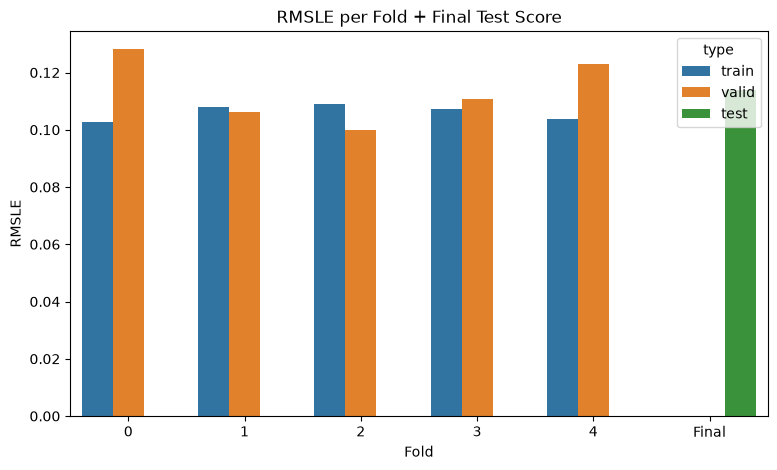

In [6]:
N_SELECT_FEATS = 30
alpha = 30.0
ridge_base = Pipeline([
    ("prep", reg_preprocessor),
    # ("select", SelectFromModel(Ridge(alpha=alpha), max_features=N_SELECT_FEATS, threshold=-np.inf)),
    ("ridge", Ridge(alpha=alpha))
])
ridge = TransformedTargetRegressor(
    regressor=ridge_base,
    transformer=log_standardize_y,
    check_inverse=False
)

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
result = cross_validate(
    ridge, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores = -result["train_score"]
valid_scores = -result["test_score"]

for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")
ridge.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, ridge.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RMSLE per Fold + Final Test Score")
plt.show()


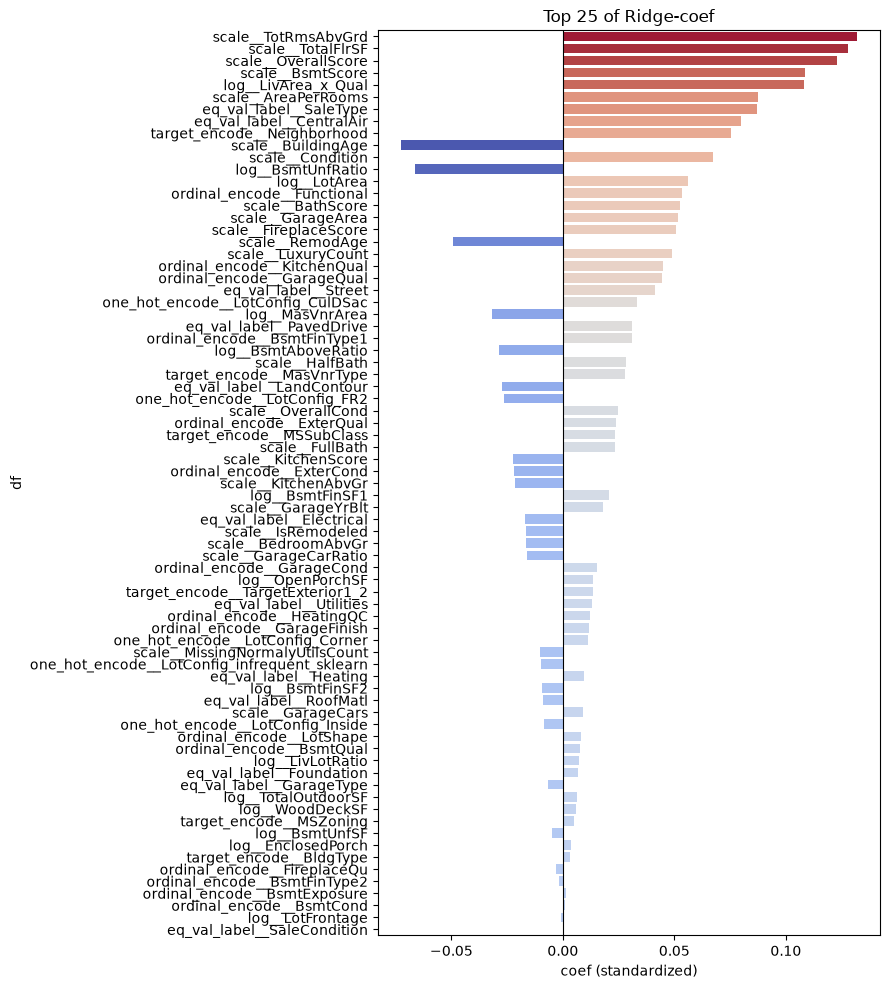

In [8]:
# 特徴量の寄与度（Ridge係数)
all_feature_names = ridge.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask = model.regressor_.named_steps["select"].get_support()
feature_names = all_feature_names  # [selected_mask]
coefs = ridge.regressor_.named_steps["ridge"].coef_

importance_df = pl.DataFrame({
    "feature": feature_names,
    "coef": coefs,
}).with_columns(
    pl.col("coef").abs().alias("abs_coef")
).sort("abs_coef", descending=True)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df.to_pandas(),
    x="coef", y="feature",
    hue="coef", palette="coolwarm", dodge=False, legend=False,
)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Top 25 of Ridge-coef")
plt.xlabel("coef (standardized)")
plt.ylabel("df")
plt.tight_layout()

plt.show()


### grid search(Ridge)

In [10]:
alpha_candidates = [5, 10, 30, 100]

# selectステップ(特徴量選択用Ridge)とridgeステップ(最終回帰用Ridge)のalphaを連動させて探索
param_grid = [
    {
        # "regressor__select__estimator__alpha": [alpha],
        "regressor__ridge__alpha": [alpha],
    }
    for alpha in alpha_candidates
]

grid_search = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
)
grid_search.fit(X_train, y_train)

# CVスコア一覧
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")
test_score = root_mean_squared_log_error(y_va, ridge.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score:.4f}")
cv_results = pd.DataFrame(grid_search.cv_results_)[
    ["param_regressor__ridge__alpha", "mean_test_score", "std_test_score"]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]
).sort_values("param_regressor__ridge__alpha")
ridge_best = grid_search.best_estimator_
cv_results



CV平均: train 0.1061 / valid 0.1136
最終スコア(test RMSLE): 0.1140


,param_regressor__ridge__alpha,mean_test_score,std_test_score,mean_test_RMSLE
0,5,-0.114199,0.009737,0.114199
1,10,-0.113847,0.009942,0.113847
2,30,-0.113633,0.010459,0.113633
3,100,-0.114513,0.011777,0.114513


### XGBoost

Fold 1: train RMSLE = 0.0853 / valid RMSLE = 0.1350
Fold 2: train RMSLE = 0.0908 / valid RMSLE = 0.1177
Fold 3: train RMSLE = 0.0927 / valid RMSLE = 0.1094
Fold 4: train RMSLE = 0.0923 / valid RMSLE = 0.1095
Fold 5: train RMSLE = 0.0894 / valid RMSLE = 0.1219
CV平均: train 0.0901 / valid 0.1187
Fold毎best_iteration: [1976, 1933, 1958, 1481, 1996]
最終スコア(test RMSLE, n_estimators=1869): 0.1256


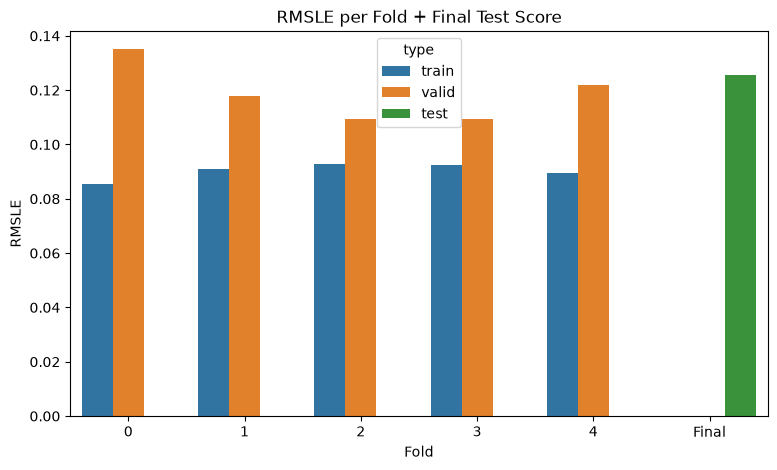

In [11]:

XGB_PARAMS = {
    # 固定
    'n_estimators': 2000,  # early stoppingが上限を決めるため大きめに設定
    'learning_rate': 0.01,
    'random_state': 42,
    'eval_metric': "rmse",
    # チューニング対象
    'colsample_bytree': 0.786,
    'colsample_bynode': 0.523,
    'gamma': 0.233,
    'max_depth': 3,
    'min_child_weight': 18,
    'reg_alpha': 0.265,
    'reg_lambda': 3.144,
    'subsample': 0.795,
}
EARLY_STOPPING_ROUNDS = 500

folds = 5
cv = KFold(n_splits=folds, shuffle=True, random_state=42)
weights = np.where(train['SalePrice'] > 300000, 2.0, 1.0)

# cross_validateはfold毎のeval_setを渡せないため、早期終了させるには手動ループが必要
train_scores = []
valid_scores = []
best_iterations = []
for tr_idx, val_idx in cv.split(X_train, y_train):
    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    y_transformer = clone(log_standardize_y)
    y_tr_trans = y_transformer.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel()
    y_val_trans = y_transformer.transform(y_val.to_numpy().reshape(-1, 1)).ravel()

    prep = clone(tree_preprocessor)
    X_tr_prep = prep.fit_transform(X_tr, y_tr)
    X_val_prep = prep.transform(X_val)

    fold_xgb = XGBRegressor(**{**XGB_PARAMS, "early_stopping_rounds": EARLY_STOPPING_ROUNDS})
    fold_xgb.fit(
        X_tr_prep, y_tr_trans,
        sample_weight=weights[tr_idx],
        eval_set=[(X_val_prep, y_val_trans)],
        verbose=False,
    )
    best_iterations.append(fold_xgb.best_iteration)

    # RMSLEは元のSalePriceスケールで計算する必要があるため逆変換する
    pred_tr = y_transformer.inverse_transform(fold_xgb.predict(X_tr_prep).reshape(-1, 1)).ravel()
    pred_val = y_transformer.inverse_transform(fold_xgb.predict(X_val_prep).reshape(-1, 1)).ravel()
    train_scores.append(root_mean_squared_log_error(y_tr, pred_tr))
    valid_scores.append(root_mean_squared_log_error(y_val, pred_val))

train_scores = np.array(train_scores)
valid_scores = np.array(valid_scores)

# スコア表示
for i, (tr, va) in enumerate(zip(train_scores, valid_scores), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores.mean():.4f} / valid {valid_scores.mean():.4f}")
print(f"Fold毎best_iteration: {best_iterations}")

# 最終モデルは早期終了なしで、fold平均のbest_iterationを木の本数として固定する
avg_best_iter = round(np.mean(best_iterations))
XGB_PARAMS_final = {**XGB_PARAMS, "n_estimators": avg_best_iter}
xgb_base = Pipeline([
    ("prep", tree_preprocessor),
    ("xgb", XGBRegressor(**XGB_PARAMS_final))
])
xgb = TransformedTargetRegressor(
    regressor=xgb_base,
    transformer=log_standardize_y,
    check_inverse=False
)
xgb.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, xgb.predict(X_va))
print(f"最終スコア(test RMSLE, n_estimators={avg_best_iter}): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(train_scores) + list(valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RMSLE per Fold + Final Test Score")
plt.show()

### RandomSearch

In [12]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import ParameterSampler

# learning_rate/n_estimatorsは固定し、正則化・複雑さ系パラメータのみランダム探索する
FIXED_XGB_PARAMS = {
    'n_estimators': 2000,
    'learning_rate': 0.01,
    'random_state': 42,
    'eval_metric': "rmse",
}

param_distributions = {
    "max_depth": randint(2, 5),
    "min_child_weight": randint(4, 31),
    "gamma": uniform(0, 1),
    "reg_alpha": loguniform(1e-2, 2.0),
    "reg_lambda": loguniform(1.0, 20.0),
    "subsample": uniform(0.5, 0.3),
    "colsample_bytree": uniform(0.3, 0.5),
    "colsample_bynode": uniform(0.5, 0.5),
}

N_ITER = 8
sampled_params_list = list(ParameterSampler(param_distributions, n_iter=N_ITER, random_state=42))


def evaluate_xgb_cv(sampled_params):
    # RandomizedSearchCVはfold毎にeval_setを渡せないため、grid search(XGBoost)セルと同じ手動ループで評価する
    fit_params = {**FIXED_XGB_PARAMS, **sampled_params, "early_stopping_rounds": EARLY_STOPPING_ROUNDS}
    fold_train_scores = []
    fold_valid_scores = []
    fold_best_iterations = []

    for tr_idx, val_idx in cv.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

        y_transformer = clone(log_standardize_y)
        y_tr_trans = y_transformer.fit_transform(y_tr.to_numpy().reshape(-1, 1)).ravel()
        y_val_trans = y_transformer.transform(y_val.to_numpy().reshape(-1, 1)).ravel()

        prep = clone(tree_preprocessor)
        X_tr_prep = prep.fit_transform(X_tr, y_tr)
        X_val_prep = prep.transform(X_val)

        fold_xgb = XGBRegressor(**fit_params)
        fold_xgb.fit(
            X_tr_prep, y_tr_trans,
            sample_weight=weights[tr_idx],
            eval_set=[(X_val_prep, y_val_trans)],
            verbose=False,
        )
        fold_best_iterations.append(fold_xgb.best_iteration)

        # RMSLEは元のSalePriceスケールで計算する必要があるため逆変換する
        pred_tr = y_transformer.inverse_transform(fold_xgb.predict(X_tr_prep).reshape(-1, 1)).ravel()
        pred_val = y_transformer.inverse_transform(fold_xgb.predict(X_val_prep).reshape(-1, 1)).ravel()
        fold_train_scores.append(root_mean_squared_log_error(y_tr, pred_tr))
        fold_valid_scores.append(root_mean_squared_log_error(y_val, pred_val))

    return np.array(fold_train_scores), np.array(fold_valid_scores), fold_best_iterations


results_records = []
fold_scores_cache = {}
for i, sampled_params in enumerate(sampled_params_list):
    train_scores_arr, valid_scores_arr, best_iterations = evaluate_xgb_cv(sampled_params)
    fold_scores_cache[i] = (train_scores_arr, valid_scores_arr, best_iterations)
    results_records.append({
        **sampled_params,
        "mean_train_rmsle": train_scores_arr.mean(),
        "mean_valid_rmsle": valid_scores_arr.mean(),
        "mean_best_iter": float(np.mean(best_iterations)),
    })
    print(f"[{i + 1}/{N_ITER}] train RMSLE = {train_scores_arr.mean():.4f}({train_scores_arr.std():.4f}) \
        / valid RMSLE = {valid_scores_arr.mean():.4f}({valid_scores_arr.std():.4f})")

cv_results_xgb = pd.DataFrame(results_records).sort_values("mean_valid_rmsle").reset_index()
cv_results_xgb.head()


[1/12] train RMSLE = 0.1085(0.0023)         / valid RMSLE = 0.1245(0.0084)
[2/12] train RMSLE = 0.1150(0.0021)         / valid RMSLE = 0.1315(0.0078)
[3/12] train RMSLE = 0.0936(0.0026)         / valid RMSLE = 0.1175(0.0085)
[4/12] train RMSLE = 0.0899(0.0029)         / valid RMSLE = 0.1188(0.0093)
[5/12] train RMSLE = 0.1088(0.0026)         / valid RMSLE = 0.1260(0.0084)
[6/12] train RMSLE = 0.0926(0.0026)         / valid RMSLE = 0.1181(0.0083)
[7/12] train RMSLE = 0.1043(0.0023)         / valid RMSLE = 0.1228(0.0091)
[8/12] train RMSLE = 0.0966(0.0024)         / valid RMSLE = 0.1211(0.0083)
[9/12] train RMSLE = 0.1090(0.0021)         / valid RMSLE = 0.1295(0.0081)
[10/12] train RMSLE = 0.0900(0.0030)         / valid RMSLE = 0.1157(0.0079)
[11/12] train RMSLE = 0.1063(0.0025)         / valid RMSLE = 0.1265(0.0089)
[12/12] train RMSLE = 0.1026(0.0027)         / valid RMSLE = 0.1228(0.0085)


,index,colsample_bynode,colsample_bytree,gamma,max_depth,min_child_weight,reg_alpha,reg_lambda,subsample,mean_train_rmsle,mean_valid_rmsle,mean_best_iter
0,9,0.638000,0.448137,0.165267,2,10,0.094245,3.264019,0.588046,0.089981,0.115745,1894.4
1,2,0.590912,0.391702,0.304242,3,15,0.011300,4.816678,0.619958,0.093606,0.117534,1963.8
2,5,0.692708,0.307983,0.230894,4,10,0.253291,12.134212,0.552009,0.092645,0.118135,1996.8
3,3,0.523333,0.786878,0.232771,3,18,0.264804,3.144811,0.794969,0.089949,0.118782,1932.4
4,7,0.921142,0.524877,0.395150,3,19,0.056413,5.522869,0.656250,0.096605,0.121093,1952.0


RandomSearch best params: {'max_depth': 2, 'min_child_weight': 10, 'gamma': np.float64(0.1652669390630025), 'reg_alpha': np.float64(0.09424525792250461), 'reg_lambda': np.float64(3.264019163413773), 'subsample': np.float64(0.5880464524154114), 'colsample_bytree': np.float64(0.4481367528520412), 'colsample_bynode': np.float64(0.6379995910112717)}
最終スコア(test RMSLE, n_estimators=1894): 0.1245


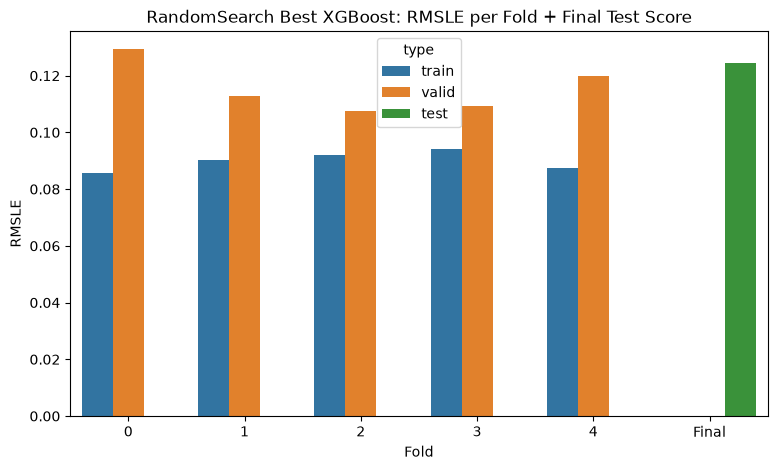

In [13]:
best_row = cv_results_xgb.iloc[0]
best_params_xgb = {k: best_row[k] for k in param_distributions}
# best_rowはSeries化で全列がfloatに揃うため、整数パラメータは明示的にintへ戻す
for int_param in ("max_depth", "min_child_weight"):
    best_params_xgb[int_param] = int(best_params_xgb[int_param])
best_original_idx = int(best_row["index"])
best_train_scores, best_valid_scores, best_iterations_list = fold_scores_cache[best_original_idx]

# RandomSearchのベストパラメータでXGB_PARAMSを更新する
XGB_PARAMS = {**FIXED_XGB_PARAMS, **best_params_xgb}
avg_best_iter = round(np.mean(best_iterations_list))
XGB_PARAMS_final = {**XGB_PARAMS, "n_estimators": avg_best_iter}

xgb_base = Pipeline([
    ("prep", tree_preprocessor),
    ("xgb", XGBRegressor(**XGB_PARAMS_final))
])
xgb = TransformedTargetRegressor(
    regressor=xgb_base,
    transformer=log_standardize_y,
    check_inverse=False
)
xgb.fit(X_train, y_train)
test_score = root_mean_squared_log_error(y_va, xgb.predict(X_va))
print(f"RandomSearch best params: {best_params_xgb}")
print(f"最終スコア(test RMSLE, n_estimators={avg_best_iter}): {test_score:.4f}")

# スコアグラフ
df = pl.DataFrame({
    "Fold": [str(i) for i in range(folds)] * 2 + ["Final"],
    "RMSLE": list(best_train_scores) + list(best_valid_scores) + [test_score],
    "type": ["train"] * folds + ["valid"] * folds + ["test"],
})

plt.figure(figsize=(9, 5))
sns.barplot(data=df, x="Fold", y="RMSLE", hue="type")

plt.title("RandomSearch Best XGBoost: RMSLE per Fold + Final Test Score")
plt.show()


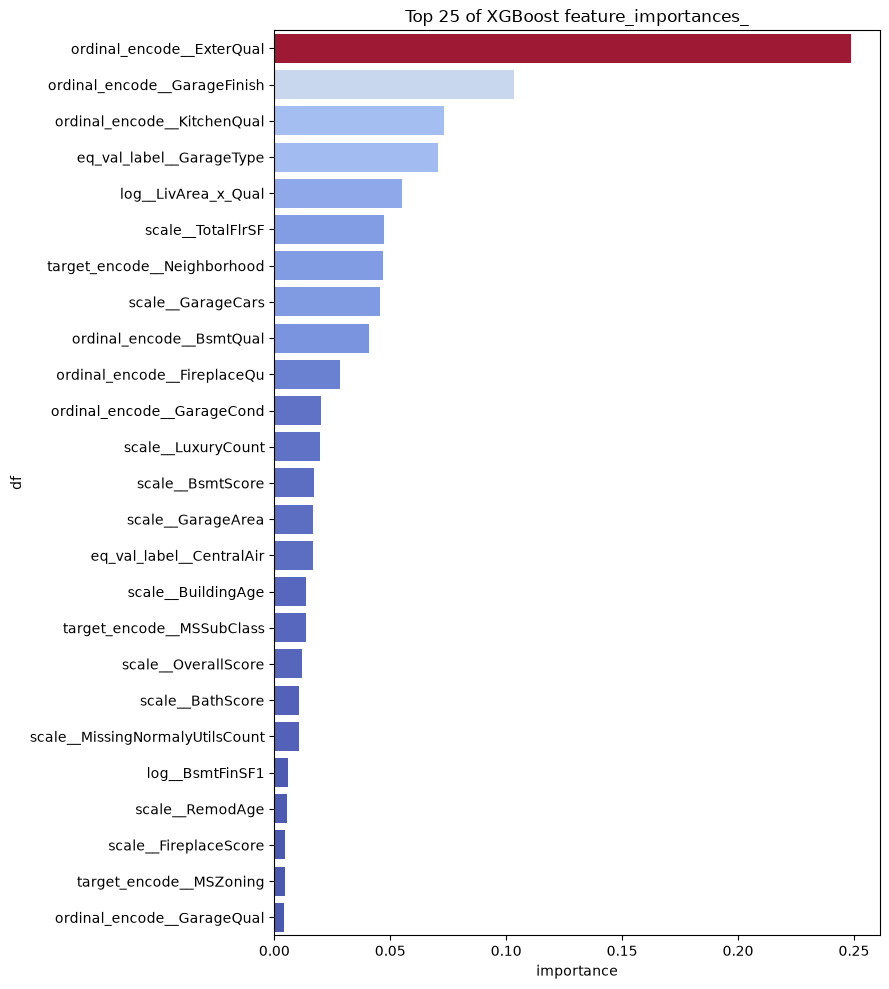

In [14]:
# 特徴量の寄与度（XGBoost feature_importances_）トップ25
all_feature_names_xgb = xgb.regressor_.named_steps["prep"].get_feature_names_out()
# selected_mask_xgb = best_model_xgb.regressor_.named_steps["select"].get_support()
feature_names_xgb = all_feature_names_xgb  # [selected_mask_xgb]
importances_xgb = xgb.regressor_.named_steps["xgb"].feature_importances_

importance_df_xgb = pl.DataFrame({
    "feature": feature_names_xgb,
    "importance": importances_xgb,
}).sort("importance", descending=True)

importance_df_xgb = importance_df_xgb.head(25)

plt.figure(figsize=(9, 10))
sns.barplot(
    data=importance_df_xgb.to_pandas(),
    x="importance", y="feature",
    hue="importance", palette="coolwarm", dodge=False, legend=False,
)
plt.title("Top 25 of XGBoost feature_importances_")
plt.xlabel("importance")
plt.ylabel("df")
plt.tight_layout()

plt.show()


In [15]:
from sklearn.inspection import permutation_importance

result_pi = permutation_importance(
    xgb, X_va, y_va,
    scoring="neg_root_mean_squared_log_error",
    n_repeats=10,
    random_state=42,
)

pi_df = pd.DataFrame({
    "feature": X_va.columns,
    "importance_mean": result_pi.importances_mean,
    "importance_std": result_pi.importances_std,
}).sort_values("importance_mean")  # neg scoreなので昇順=悪化が大きい順

pi_df.sort_values("importance_mean", ascending=False).head(25)

,feature,importance_mean,importance_std
90,LivArea_x_Qual,0.073372,0.002265
81,TotalFlrSF,0.038631,0.002833
11,Neighborhood,0.019196,0.001907
79,OverallScore,0.011626,0.001363
17,OverallCond,0.004862,0.001026
40,CentralAir,0.004641,0.000333
52,KitchenQual,0.004359,0.001100
80,BathScore,0.004230,0.000886
84,BuildingAge,0.004190,0.000869
101,BsmtScore,0.003755,0.001148


### SVR (kernel=rbf)

In [16]:
base_model_svr = Pipeline([
    ("prep", reg_preprocessor),
    ("svr", SVR(
        kernel="rbf",
        C=10,
        epsilon=0.05,
        gamma=0.001,
    ))
])
model_svr = TransformedTargetRegressor(
    regressor=base_model_svr,
    transformer=log_standardize_y,
    check_inverse=False
)

result_svr = cross_validate(
    model_svr, X_train, y_train,
    cv=cv,
    scoring="neg_root_mean_squared_log_error",
    return_train_score=True,
)

# スコア表示
train_scores_svr = -result_svr["train_score"]
valid_scores_svr = -result_svr["test_score"]

for i, (tr, va) in enumerate(zip(train_scores_svr, valid_scores_svr), 1):
    print(f"Fold {i}: train RMSLE = {tr:.4f} / valid RMSLE = {va:.4f}")
print(f"CV平均: train {train_scores_svr.mean():.4f} / valid {valid_scores_svr.mean():.4f}")
model_svr.fit(X_train, y_train)
test_score_svr = root_mean_squared_log_error(y_va, model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_svr:.4f}")

Fold 1: train RMSLE = 0.0928 / valid RMSLE = 0.1269
Fold 2: train RMSLE = 0.0967 / valid RMSLE = 0.1124
Fold 3: train RMSLE = 0.1013 / valid RMSLE = 0.1044
Fold 4: train RMSLE = 0.0994 / valid RMSLE = 0.1187
Fold 5: train RMSLE = 0.0959 / valid RMSLE = 0.1305
CV平均: train 0.0972 / valid 0.1186
最終スコア(test RMSLE): 0.1187


### grid search (SVR)

In [ ]:
param_dist_svr = {
    "regressor__svr__C": [1.0, 2.0, 10.0],
    "regressor__svr__epsilon": [0.01, 0.02, 0.05],
    "regressor__svr__gamma": [0.0005, 0.001, 0.005],
}

random_search_svr = RandomizedSearchCV(
    estimator=model_svr,
    param_distributions=param_dist_svr,
    scoring="neg_root_mean_squared_log_error",
    cv=cv,
    n_iter=100,
    n_jobs=-1,
    refit=True,
    random_state=42,
)
random_search_svr.fit(X_train, y_train)

print(f"Best params: {random_search_svr.best_params_}")
print(f"Best CV RMSLE: {-random_search_svr.best_score_:.4f}")

best_model_svr = random_search_svr.best_estimator_
test_score_gs_svr = root_mean_squared_log_error(y_va, best_model_svr.predict(X_va))
print(f"最終スコア(test RMSLE): {test_score_gs_svr:.4f}")

# パラメータごとのCVスコア一覧
cv_results_svr = pd.DataFrame(random_search_svr.cv_results_)[
    [
        "param_regressor__svr__C",
        "param_regressor__svr__epsilon",
        "param_regressor__svr__gamma",
        "mean_test_score",
        "std_test_score"
    ]
].assign(
    mean_test_RMSLE=lambda df: -df["mean_test_score"]

).sort_values("mean_test_RMSLE")
cv_results_svr.sort_values('mean_test_RMSLE',ascending=True).head(15)

### stacking

In [ ]:
from itertools import product

def compute_sample_weight(y, threshold=350000, weight=5.0):
    # 上位10%程度の高額帯(閾値以上)を重視して学習させる固定重み
    return np.where(y >= threshold, weight, 1.0)

sample_weight_train = compute_sample_weight(y_train)

base_models = {
    "ridge": ridge_best,
    "xgb": xgb,
    "svr": best_model_svr,
}

# 各モデルをX_trainでsample_weight付き再学習し、X_vaで評価する
fitted_models = {
    name: clone(model).fit(X_train, y_train, **{f"{name}__sample_weight": sample_weight_train})
    for name, model in base_models.items()
}
preds_va = {name: model.predict(X_va) for name, model in fitted_models.items()}

# 重みを0.1刻みで総当たりし、valid RMSLEが最小になる組を探す
weight_grid = [w / 10 for w in range(11)]
best_score = np.inf
best_weights = None
for w_ridge, w_xgb in product(weight_grid, repeat=2):
    w_svr = 1 - w_ridge - w_xgb
    if w_svr < 0:
        continue
    blend_va = w_ridge * preds_va["ridge"] + w_xgb * preds_va["xgb"] + w_svr * preds_va["svr"]
    score = root_mean_squared_log_error(y_va, blend_va)
    if score < best_score:
        best_score = score
        best_weights = {"ridge": w_ridge, "xgb": w_xgb, "svr": w_svr}

print(f"Best weights: {best_weights}")
print(f"Best blended RMSLE (valid): {best_score:.4f}")

for name, pred in preds_va.items():
    print(f"{name}: valid RMSLE = {root_mean_squared_log_error(y_va, pred):.4f}")

### Final Model (submit)

In [ ]:
from sklearn.base import clone

# 探索済みの重みで、全学習データ+sample_weight再学習後の予測をブレンドして提出ファイルを作成
sample_weight_full = compute_sample_weight(y)
final_models = {
    name: clone(model).fit(X, y, **{f"{name}__sample_weight": sample_weight_full})
    for name, model in base_models.items()
}
preds_test = {name: model.predict(X_test) for name, model in final_models.items()}

# pred_final = (
#     best_weights["ridge"] * preds_test["ridge"]
#     + best_weights["xgb"] * preds_test["xgb"]
#     + best_weights["svr"] * preds_test["svr"]
# )
pred_final = (
    preds_test["ridge"]
 )

pd.DataFrame({
    "Id": test.index,
    "SalePrice": pred_final
}).to_csv("../../data/temp_ridge_submission(base_v2).csv", index=False)

In [ ]:
preds_train = {name: model.predict(X_train) for name, model in fitted_models.items()}
blend_train = (
    best_weights["ridge"] * preds_train["ridge"]
    + best_weights["xgb"] * preds_train["xgb"]
    + best_weights["svr"] * preds_train["svr"]
)

plt.figure(figsize=(8, 8))
for name, pred in {**preds_train, "Blend": blend_train}.items():
    plt.scatter(y_train, pred, alpha=0.4, label=name, s=15)

lims = [y_train.min(), y_train.max()]
plt.plot(lims, lims, "k--", linewidth=1)
plt.xlabel("True SalePrice (train)")
plt.ylabel("Predicted SalePrice (train)")
plt.title("True vs Predicted (train) by model")
plt.legend()
plt.tight_layout()
plt.show()
